In [1]:
from importlib.metadata import PackageNotFoundError, version
import sys

required_versions = {
    "flax": "0.12.9",
    "jax": "0.11.1",
    "jaxlib": "0.11.1",
    "jraph": "0.0.6.dev0",
    "optax": "0.2.8",
    "e3nn-jax": "0.21.0",
    "numpy": "2.4.6",
    "matplotlib": "3.11.2",
    "matplotlib-inline": "0.2.2",
}
mismatches = []
for package, expected in required_versions.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = "not installed"
    if installed != expected:
        mismatches.append(f"{package}: expected {expected}, found {installed}")

if mismatches:
    if "google.colab" not in sys.modules:
        raise ModuleNotFoundError(
            "The E3NN notebook environment does not match its pins:\n"
            + "\n".join(mismatches)
            + "\nRun scripts/run_e3nn_notebook.sh book/up/symmetries/02_e3nn.ipynb."
        )
    %pip install jax==0.11.1 jaxlib==0.11.1 flax==0.12.9 jraph==0.0.6.dev0 optax==0.2.8 e3nn_jax==0.21.0 numpy==2.4.6 matplotlib==3.11.2 matplotlib-inline==0.2.2
    print("If Colab upgraded an already imported package, restart the runtime and rerun the notebook.")

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Euclidean neural networks




This activity adapts and modifies the official [E3NN-JAX point-cloud example, version 0.21.0](https://github.com/e3nn/e3nn-jax/blob/04e761c8e9a42c339cc712fb8b9af85ddd618eab/examples/tetris_point.py), distributed under the [Apache License 2.0](https://github.com/e3nn/e3nn-jax/blob/04e761c8e9a42c339cc712fb8b9af85ddd618eab/LICENSE). The exposition, figures, exercises, and explicit transformation tests are modifications for this book.

We classify eight four-block pieces represented as point clouds in $\mathbb{R}^3$. Rotations and translations leave every class label unchanged. A reflection exchanges the first two labels, which form a chiral mirror pair, and leaves the six achiral labels unchanged. The internal features transform equivariantly, and the readout implements this action on the labels.

In [3]:
# Local execution is pinned by book/requirements-e3nn.txt and
# scripts/run_e3nn_notebook.sh. The installation cell above is only a Colab fallback.

In [4]:
import time
import flax
import jax
import jax.random as jr
import jax.numpy as jnp
import jraph
import optax
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D
import e3nn_jax as e3nn

Each piece consists of four blocks. We represent the block centers by a matrix $X\in\mathbb{R}^{4\times 3}$, whose $i$th row contains the three coordinates of block $i$. The eight matrices below define the classification data.

In [5]:
# Define block positions for the different shapes
pos = jnp.array([
    [[0, 0, 0], [0, 0, 1], [1, 0, 0], [1, 1, 0]],  # chiral_shape_1
    [[1, 1, 1], [1, 1, 2], [2, 1, 1], [2, 0, 1]],  # chiral_shape_2
    [[0, 0, 0], [1, 0, 0], [0, 1, 0], [1, 1, 0]],  # square
    [[0, 0, 0], [0, 0, 1], [0, 0, 2], [0, 0, 3]],  # line
    [[0, 0, 0], [0, 0, 1], [0, 1, 0], [1, 0, 0]],  # corner
    [[0, 0, 0], [0, 0, 1], [0, 0, 2], [0, 1, 0]],  # L
    [[0, 0, 0], [0, 0, 1], [0, 0, 2], [0, 1, 1]],  # T
    [[0, 0, 0], [1, 0, 0], [1, 1, 0], [2, 1, 0]],  # zigzag
], dtype=jnp.float32)

# Define the labels for the different shapes
labels = jnp.arange(8)

# Create a dictionary with the labels to each shape name
shape_names = {
    0: "chiral_shape_1",
    1: "chiral_shape_2",
    2: "square",
    3: "line",
    4: "corner",
    5: "L",
    6: "T",
    7: "zigzag",
}

To display each piece as a graph, we connect two distinct block centers whenever their Euclidean distance is at most $1.1$. This rule joins face-adjacent unit blocks and is unchanged by every Euclidean transformation.

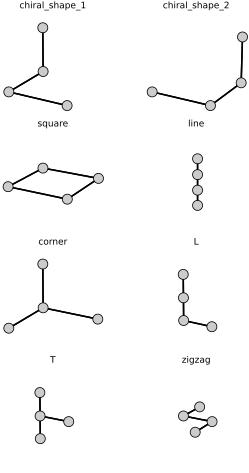

In [6]:
# Compute edges based on proximity
def compute_edges(p, radius=1.1):
    """Compute edges between nodes within a given radius."""
    senders = []
    receivers = []
    num_nodes = p.shape[0]
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i != j:
                distance = jnp.linalg.norm(p[i] - p[j])
                if distance <= radius:
                    senders.append(i)
                    receivers.append(j)
    return senders, receivers

# Lets make a helper function to plot the shapes
def plot_shapes(pos, names):
    """
    Plot the different shapes in 3D.

    Parameters:
    - pos: a JAX array of shape [num_shapes, num_nodes, 3], positions of nodes
    - shape_names: a dictionary mapping from index to shape name
    """
    num_shapes = len(pos)
    if num_shapes > 4:
        nrows, ncols, figsize = 4, 2, (4.5, 6.6)
    else:
        ncols = min(2, num_shapes)
        nrows = int(np.ceil(num_shapes / ncols))
        figsize = (4.5, 2.4 * nrows)
    fig = plt.figure(facecolor="white", figsize=figsize)

    for idx, p in enumerate(pos):
        # Compute edges based on proximity
        senders, receivers = compute_edges(p, radius=1.1)

        ax = fig.add_subplot(nrows, ncols, idx + 1, projection="3d", facecolor="white")
        ax.set_axis_off()
        ax.set_title(names[idx])

        # Plot nodes
        x, y, z = p[:, 0], p[:, 1], p[:, 2]
        ax.scatter(x, y, z, c="0.8", s=100, edgecolors="black", depthshade=False)

        # Plot edges
        for sender, receiver in zip(senders, receivers):
            x_coords = [p[sender][0], p[receiver][0]]
            y_coords = [p[sender][1], p[receiver][1]]
            z_coords = [p[sender][2], p[receiver][2]]
            ax.plot(x_coords, y_coords, z_coords, c="black", linewidth=1.5)

        # Set equal aspect ratio
        x_range = x.max() - x.min()
        y_range = y.max() - y.min()
        z_range = z.max() - z.min()
        max_range = jnp.array([x_range, y_range, z_range]).max() / 2.0
        mid_x = (x.max() + x.min()) * 0.5
        mid_y = (y.max() + y.min()) * 0.5
        mid_z = (z.max() + z.min()) * 0.5
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)

        # Adjust viewing angle
        ax.view_init(elev=20, azim=30)

    fig.tight_layout(pad=0.25)
    plt.show()

# Plot the shapes
plot_shapes(pos, shape_names)

A Euclidean transformation preserves all pairwise distances, but an improper transformation can change handedness. The next figure reflects the first chiral class so that we can see the required change in its label.

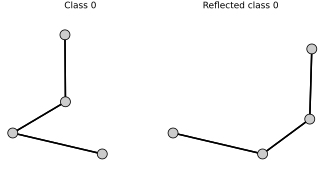

In [7]:
# Reflect through the xz-plane
reflection = jnp.array([[1, 0, 0], 
                        [0, -1, 0], 
                        [0, 0, 1]], dtype=jnp.float32)

# Apply the transformation to the positions
reflected_shape = jnp.einsum("ij,nj->ni", reflection, pos[0])

names = {0: "Class 0", 1: "Reflected class 0"}

# Plot the shapes
plot_shapes(jnp.stack([pos[0], reflected_shape]), names)

The matrix $A=\operatorname{diag}(1,-1,1)$ has determinant $-1$ and reflects points through the $xz$-plane. The reflected coordinates equal the coordinates of class 1 after adding $(1,1,1)$, so the reflection exchanges classes 0 and 1. Proper rotations and translations preserve every class label.

We encode each piece with [Jraph](https://jraph.readthedocs.io/en/latest/index.html). Each block becomes a node, and the distance rule defines the directed edges. The graph-level `globals` field stores the class label; it is not an additional node, and the model's update functions never use it as an input feature. Because the geometry does not depend on the order in which the four blocks are listed, the classifier must also be invariant to a permutation of the node labels.

In [8]:
# Create a function to create the graphs
def create_tetrisGraphs(positions: jax.Array, 
                        labels: jax.Array
                        ) -> jraph.GraphsTuple:
    
    # Initialize an empty list to store the graphs
    graphs = []

    # Loop over each shape and create a graph for each
    for p, l in zip(positions, labels):

        # Precompute edges based on proximity
        senders, receivers = e3nn.radius_graph(p, 1.1)

        # Use jraph to create a graph
        graphs += [
            jraph.GraphsTuple(
                nodes=p.reshape((4, 3)),  # [num_nodes, 3]
                edges=None,
                globals=l[None],  # [num_graphs]
                senders=senders,  # [num_edges]
                receivers=receivers,  # [num_edges]
                n_node=jnp.array([len(p)]),  # [num_graphs]
                n_edge=jnp.array([len(senders)]),  # [num_graphs]
            )
        ]

    # Return the batched graphs
    return jraph.batch(graphs)

# Create the dataset
graphs = create_tetrisGraphs(pos, labels)

An equivariant message-passing layer builds angular features from the relative displacement $\mathbf r_{ij}=\mathbf r_j-\mathbf r_i$. Write $r=\lVert\mathbf r_{ij}\rVert$ and $\widehat{\mathbf r}=\mathbf r_{ij}/r$. A standard spherical-harmonic kernel channel has the form

$$
W_{\ell m}(\mathbf r_{ij})=R_\ell(r)Y_{\ell m}(\widehat{\mathbf r}),
$$

where $R_\ell$ is a learned radial function and $Y_{\ell m}$ is a spherical harmonic. The compact layer used below omits the learned radial function: a distance cutoff selects the edges, and its messages use spherical harmonics and tensor products. The displayed kernel describes the more general construction {cite:p}`geiger2022e3nn`.

For a fixed degree $\ell$, the $2\ell+1$ components $Y_{\ell m}$ form a basis for an irreducible representation. Their known rotation and reflection laws let the network convert geometry into features whose transformation types remain explicit.

The next plot shows one component of these angular features.

Change the value of ``ell`` to see different harmonics. The labels ``e`` and ``o`` record even and odd parity. For ordinary spherical harmonics evaluated on a polar direction, parity is fixed by the degree: $Y_{\ell m}(-\hat{r})=(-1)^\ell Y_{\ell m}(\hat{r})$. The consistent choices in this visualization are therefore

- ``ell = 0e``: a constant scalar component, unchanged under parity;
- ``ell = 1o``: a dipolar component, which changes sign under parity;
- ``ell = 2e``: a quadrupolar component, unchanged under parity; and
- ``ell = 3o``: a higher odd component, which changes sign under parity.

An $O(3)$ irrep may also carry the opposite parity. For example, ``1e`` is an axial-vector type that can arise from the tensor product of two polar-vector features, as in a cross product. It is not obtained by evaluating degree-one spherical harmonics on a single polar direction. The plot below displays the $m=0$ component of the selected harmonic. Radial distance represents $|Y_{\ell 0}|$; the light unhatched lobe is nonnegative, and the dark hatched lobe is negative.


In [9]:
ell = "1o"

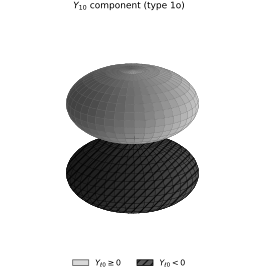

In [10]:
alpha = jnp.linspace(0, 2 * jnp.pi, 121)
beta = jnp.linspace(0, jnp.pi, 61)
alpha, beta = jnp.meshgrid(alpha, beta, indexing="ij")
vectors = e3nn.angles_to_xyz(alpha, beta)
polar_directions = e3nn.IrrepsArray("1o", vectors)

signal_components = e3nn.spherical_harmonics(
    ell, polar_directions, normalize=True, normalization="component"
).array
m_zero_index = signal_components.shape[-1] // 2
signal = np.asarray(signal_components[:, :, m_zero_index])
directions = np.asarray(vectors)
radius = np.abs(signal)
# E3NN uses the y-axis as the polar axis; map it to Matplotlib's vertical z-axis.
x = radius * directions[:, :, 0]
y = radius * directions[:, :, 2]
z = radius * directions[:, :, 1]
positive = signal >= 0
negative = signal < 0

fig = plt.figure(figsize=(4.5, 3.8), facecolor="white")
ax = fig.add_subplot(111, projection="3d")
positive_surface = ax.plot_surface(
    np.where(positive, x, np.nan),
    np.where(positive, y, np.nan),
    np.where(positive, z, np.nan),
    color="0.85", edgecolor="0.35", linewidth=0.15, antialiased=True, shade=True,
)
negative_surface = ax.plot_surface(
    np.where(negative, x, np.nan),
    np.where(negative, y, np.nan),
    np.where(negative, z, np.nan),
    color="0.35", edgecolor="black", linewidth=0.25, antialiased=True, shade=True,
)
negative_surface.set_hatch("///")
ax.set_box_aspect((1, 1, 1))
ax.set_proj_type("ortho")
ax.view_init(elev=18, azim=-65)
ax.set_axis_off()
degree = e3nn.Irrep(ell).l
ax.set_title(rf"$Y_{{{degree}0}}$ component (type {ell})")
ax.legend(
    handles=[
        Patch(facecolor="0.85", edgecolor="0.35", label=r"$Y_{\ell 0} \geq 0$"),
        Patch(facecolor="0.35", edgecolor="black", hatch="///", label=r"$Y_{\ell 0} < 0$"),
    ],
    loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=2,
)
fig.tight_layout(pad=0.25)
plt.show()

Now consider the tensor product of two irreducible representations. The tensor product is generally reducible: it decomposes as a direct sum of irreps according to the angular-momentum coupling rules.

In [11]:
irrep1 = e3nn.Irreps("1e")
irrep2 = e3nn.Irreps("2o")

tp = e3nn.tensor_product(irrep1, irrep2)
print(tp)

1x1o+1x2o+1x3o


Here $1e\otimes 2o$ decomposes into the `Irreps` collection $1o\oplus 2o\oplus 3o$. The next direct sum is a separate target representation for the linear-layer example; it is not this tensor-product decomposition.

In [12]:
irrep3 = e3nn.Irreps("1e + 2o + 3o")
print(irrep3)

1x1e+1x2o+1x3o


An equivariant linear layer can mix copies of the same irrep, but it cannot map between inequivalent transformation types. The following example requests output types ``1e + 2o + 3o`` from an input containing only ``2o + 3o``.

In [13]:
# Define a linear layer
layer = e3nn.flax.Linear(irrep3)

# Randomly initialize non-zero weights for two of the irreps
x = e3nn.normal("2o + 3o", jr.PRNGKey(0))
w = layer.init(jr.PRNGKey(0), x)

# Apply the layer to the input
y = layer.apply(w, x)
print(y.irreps)

1x2o+1x3o


The output omits the requested ``1e`` channel. This is a structural consequence of representation matching, not a learned judgment: an equivariant linear map cannot create a ``1e`` component from an input containing only ``2o + 3o``. The allowed linear weights can then be learned through backpropagation while the representation constraints preserve equivariance.

We now assemble these operations into the graph classifier.

The implementation uses [E3NN-JAX](https://e3nn-jax.readthedocs.io/) with [Flax](https://flax-linen.readthedocs.io/en/latest/). Each message combines a sender feature with spherical harmonics of the relative position. Equivariant linear maps select the requested output types, and scalar activations supply nonlinearity without changing the transformation laws.

In [14]:
class Layer(flax.linen.Module):
    target_irreps: e3nn.Irreps
    denominator: float
    # The maximum degree of the spherical harmonics
    sh_lmax: int = 3

    @flax.linen.compact
    def __call__(self, graphs, positions):
        # Define the target irreps
        target_irreps = e3nn.Irreps(self.target_irreps)

        def update_edge_fn(edge_features, sender_features, receiver_features, globals):
            # Compute the spherical harmonics for up to sh_lmax
            sh = e3nn.spherical_harmonics(
                list(range(1, self.sh_lmax + 1)),
                positions[graphs.receivers] - positions[graphs.senders],
                True,
            )
            # Perform tensor product with the sender features
            return e3nn.concatenate(
                [sender_features, e3nn.tensor_product(sender_features, sh)]
            ).regroup()

        def update_node_fn(node_features, sender_features, receiver_features, globals):
            # Scale the receiver features
            node_feats = receiver_features / self.denominator
            # Apply a linear layer to the node features
            node_feats = e3nn.flax.Linear(target_irreps, name="linear_pre")(node_feats)
            # Apply an activation function to introduce non-linearity
            node_feats = e3nn.scalar_activation(node_feats)
            # Apply another linear layer to the node features
            node_feats = e3nn.flax.Linear(target_irreps, name="linear_post")(node_feats)
            shortcut = e3nn.flax.Linear(
                node_feats.irreps, name="shortcut", force_irreps_out=True
            )(node_features)
            return shortcut + node_feats

        # Apply the update functions to the Graph Network
        return jraph.GraphNetwork(update_edge_fn, update_node_fn)(graphs)

The position of each block is a polar vector of type ``1o``. The initial node feature is the constant scalar $1$, of type ``0e``. Relative positions make the messages translation invariant, while spherical harmonics, tensor products, and equivariant linear maps control their behavior under $O(3)$.

Three message-passing layers use the feature types ``32x0e + 32x0o + 8x1e + 8x1o + 8x2e + 8x2o``. A fourth layer produces one odd scalar and seven even scalars. Summation over nodes is invariant to node relabeling and retains these transformation types at graph level. If $a$ denotes the odd scalar after an even gate and $b_2,\ldots,b_7$ denote the remaining even scalars, the logits are $(a,-a,b_2,\ldots,b_7)$. A reflection sends $a$ to $-a$, thereby exchanging the first two logits while leaving the other six fixed. This is exactly the required action on the class labels.


In [15]:
class Model(flax.linen.Module):
    @flax.linen.compact
    def __call__(self, graphs):
        positions = e3nn.IrrepsArray("1o", graphs.nodes)
        graphs = graphs._replace(nodes=jnp.ones((len(positions), 1)))

        layers = 3 * ["32x0e + 32x0o + 8x1e + 8x1o + 8x2e + 8x2o"] + ["0o + 7x0e"]

        for irreps in layers:
            graphs = Layer(irreps, 1.5)(graphs, positions)

        # Readout logits
        pred = e3nn.scatter_sum(
            graphs.nodes.array, nel=graphs.n_node
        )  # [num_graphs, 1 + 7]
        odd, even1, even2 = pred[:, :1], pred[:, 1:2], pred[:, 2:]
        logits = jnp.concatenate([odd * even1, -odd * even1, even2], axis=1)
        assert logits.shape == (len(graphs.n_node), 8)  # [num_graphs, num_classes]

        return logits

We train on one orientation of each of the eight pieces using softmax cross-entropy. No rotated, translated, reflected, or node-permuted copies are added to the training set; the transformation laws are imposed by the architecture.

In [16]:
# Model initialization
model = Model()

# Optimizer initialization
opt = optax.adam(learning_rate=0.01)

# Define the classification loss function
def loss_fn(params, graphs):
    logits = model.apply(params, graphs)
    labels = graphs.globals  # [num_graphs]

    loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels)
    loss = jnp.mean(loss)
    return loss, logits

# Define the update step
@jax.jit
def update_fn(params, opt_state, graphs):
    grad_fn = jax.grad(loss_fn, has_aux=True)
    grads, logits = grad_fn(params, graphs)
    labels = graphs.globals
    accuracy = jnp.mean(jnp.argmax(logits, axis=1) == labels)

    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, accuracy

# Initiation
init = jax.jit(model.init)
params = init(jax.random.PRNGKey(3), graphs)
opt_state = opt.init(params)

# Training Loop
steps = 100
print_freq = 5
wall = time.perf_counter()
print("Training", flush=True)

for i in range(steps):
    params, opt_state, accuracy = update_fn(params, opt_state, graphs)

    if i % print_freq == 0:
        print(f"step {i}: accuracy = {100 * accuracy:.2f}%", flush=True)

    if accuracy == 1.0:
        print(f"early stopping at step {i}")
        break

print(f"final accuracy = {100 * accuracy:.0f}%")

Training


step 0: accuracy = 12.50%


step 5: accuracy = 37.50%


step 10: accuracy = 75.00%


step 15: accuracy = 87.50%


early stopping at step 17
final accuracy = 100%


The training examples are classified correctly. We now test three transformations that were absent from the training set: a rotation and translation, a reflection, and a permutation of the four node labels.

The helper below rebuilds the radius graph after a transformation and returns the graph-level logits.

In [17]:
def logits_for_shape(shape):
    senders, receivers = e3nn.radius_graph(shape, 1.1)
    transformed_graph = jraph.GraphsTuple(
        nodes=shape.reshape((4, 3)),
        edges=None,
        globals=jnp.array([-1]),  # The model does not use this field.
        senders=senders,
        receivers=receivers,
        n_node=jnp.array([4]),
        n_edge=jnp.array([len(senders)]),
    )

    transformed_graph = jraph.batch([transformed_graph])
    return model.apply(params, transformed_graph)[0]

def test_transform(transformed_shape, expected_class):
    logits = logits_for_shape(transformed_shape)
    predicted_class = int(jnp.argmax(logits))
    print(f"Predicted class: {predicted_class}; expected class: {expected_class}")
    return logits

Shape: chiral_shape_2


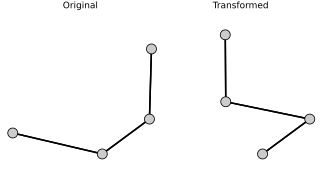

Predicted class: 1; expected class: 1
Rotation/translation logit error: 7.63e-06
Predicted class: 1; expected class: 1


Reflection-equivariance logit error: 0.00e+00
Node-permutation logit error: 0.00e+00


In [18]:
# Test a proper Euclidean transformation
shape_idx = 1
print(f"Shape: {shape_names[shape_idx]}")

rotation = jnp.array([[0, -1, 0], 
                      [1, 0, 0], 
                      [0, 0, 1]], dtype=jnp.float32)

translation = jnp.array([2, -1, 3], dtype=jnp.float32)

original_shape = pos[shape_idx]
rotated = jnp.einsum("ij,nj->ni", rotation, original_shape)
translated = rotated + translation

plot_shapes(jnp.stack([pos[shape_idx], translated]), 
            {0: "Original", 1: "Transformed"})

original_logits = logits_for_shape(original_shape)
proper_logits = test_transform(translated, shape_idx)
proper_error = jnp.max(jnp.abs(proper_logits - original_logits))
print(f"Rotation/translation logit error: {proper_error:.2e}")

# Test the improper action on the chiral pair
reflected_chiral = jnp.einsum("ij,nj->ni", reflection, pos[0]) + translation
reflected_logits = test_transform(reflected_chiral, 1)
base_chiral_logits = logits_for_shape(pos[0])
label_action = jnp.array([1, 0, 2, 3, 4, 5, 6, 7])
reflection_error = jnp.max(
    jnp.abs(reflected_logits - base_chiral_logits[label_action])
)
print(f"Reflection-equivariance logit error: {reflection_error:.2e}")

# Test invariance to node relabeling
node_order = jnp.array([2, 0, 3, 1])
permuted_logits = logits_for_shape(original_shape[node_order])
permutation_error = jnp.max(jnp.abs(permuted_logits - original_logits))
print(f"Node-permutation logit error: {permutation_error:.2e}")

assert int(jnp.argmax(proper_logits)) == shape_idx
assert int(jnp.argmax(reflected_logits)) == 1
assert proper_error < 1e-4
assert reflection_error < 1e-4
assert permutation_error < 1e-4

The proper transformation leaves the logits unchanged up to floating-point error. The reflection swaps the first two logits, and the node permutation leaves all logits unchanged. These identities test the architectural transformation laws directly; the separate training accuracy only shows that the model fitted the eight prototypes.

The model therefore has the required $E(3)$ behavior: rotations and translations preserve every class, while reflections exchange the chiral pair and preserve the achiral classes.

Equivariant networks can also serve as data-efficient surrogates for atomistic simulations. NequIP, for example, uses $E(3)$-equivariant graph convolutions to learn interatomic potentials for molecular dynamics {cite:p}`batzner2022e3equivariant`.

## Exercises

1. Derive the action of a reflection on the logits $(a,-a,b_2,\ldots,b_7)$ and explain why comparing a reflected chiral piece with its original label would test the wrong invariance property.

2. Replace the node ordering by a different permutation and verify that the logits remain unchanged. Identify the aggregation operations in the network that enforce this invariance.

3. Explain why the spherical harmonics of a single polar direction have parity $(-1)^\ell$, while an axial feature of type ``1e`` can arise from a tensor product of polar-vector features.